## Calculating R* using SciKit Leanrn's HistGradientBoostClassifier Model. 


The first step is to load in a MaCh3 MCMC fit as input file. This is done using the ChainHandler class!

In [1]:
# MaCh3Python Deps
from MaCh3PythonUtils.file_handling.chain_handler import ChainHandler
from MaCh3PythonUtils.machine_learning.ml_factory import MLFactory
from MaCh3PythonUtils.file_handling.chain_diagnostics import ChainDiagnostics
from sklearn.model_selection import LearningCurveDisplay
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import log_loss    


# Other imports
from matplotlib import pyplot as plt
from pathlib import Path
import numpy as np
import random as rand
import os
import pandas as pd
import seaborn as sns
import gdown

Using mps device

### Adding Chain IDs to each individual chains

I am working with MCMC chains generated from T2K and NOvA data. The folders contain non-adaptive and adaptive MCMC chains, both of which have its own T2K and NOvA runs. TLDR; the code grabs each file in the user-specified folder and then adds Chain IDs to them.

- Once the user has defined the path to the directory that contains the .root files (chain files), the code below takes each .root file in that directory and passes it through a `ChainHandler` instance which can manipulate what data Python is able to read; adds and removes plots. 

- It then adds the Chain IDs onto the seperate files; IDs start from 0 and end at N for N files in that directory. The IDs are for the ML Classifier. 
- Finally, it stitches all the files into one big pandas DataFrame; this is what the model is trained and tested on.

In [2]:

#file_url="https://drive.google.com/file/d/1iE6xFhn3BH_HnLUfQ7KFGy2wfeH52Rwf/view?usp=sharing"


path_NoAd_T2K= Path("../models/demo_files 2/NoAdapt/T2K")
path_NoAd_Nova= Path('../models/demo_files 2/NoAdapt/NOvA')
path_Ad_T2K= Path('../models/demo_files 2/Adapt/T2K')
path_Ad_Nova= Path('../models/demo_files 2/Adapt/NOvA')

NAD_T2K=[f"{path_NoAd_T2K}/{x}" for x in os.listdir(path_NoAd_T2K)] 
NAD_Nova=[f'{path_NoAd_Nova}/{y}' for y in os.listdir(path_NoAd_Nova)]
AD_T2K=[f'{path_Ad_T2K}/{z}' for z in os.listdir(path_Ad_T2K)]
AD_Nova=[f'{path_Ad_Nova}/{a}' for a in os.listdir(path_Ad_Nova)]# these will be used later as args in functions (used to calc the dims of the data)

print(NAD_T2K)
print(NAD_Nova)
print(AD_T2K)
print(AD_Nova)


fitting_label = "ID"
paths = [NAD_T2K, NAD_Nova, AD_T2K, AD_Nova]
# chain_list [for file in folder ChainHandler(input_file, chain_name, verbose=verbse)]: Handler List : Hlist

TEMP_NAD_T2K_list = []
TEMP_NAD_Nova_list = []
TEMP_AD_T2K_list = []
TEMP_AD_Nova_list = []

for lm in paths:
    for x in lm:
        chain_handler = ChainHandler(x, 'posteriors', verbose='verbose')
            
        # Process all the files
        chain_handler.ignore_plots(["xsec_20", "xsec_19"])
        chain_handler.add_additional_plots(["xsec_0", "xsec_1", "xsec_2", "xsec_3", "xsec_4", "xsec_5", "xsec_6", "xsec_7", "xsec_8", "xsec_9", "xsec_10", "xsec_11", "xsec_12", "xsec_13",
                                            "xsec_14", "xsec_15", "xsec_16", "xsec_17", "xsec_18", "xsec_21", "xsec_22"])
        #We need to make sure the chain handler knows this exists, passing true means it is looking for some with that exact name
        # chain_handler.add_additional_plots(fitting_label, True)

        # Finally we can do some cuts to get rid of things like burn-in
        chain_handler.add_new_cuts(["LogL<22.5", "step>10000", "delm2_23>0"])
        chain_handler.add_new_cuts(["step>0", "LogL_systematic_xsec_cov<12345"])

        # Last step is  convert the chain data files into a pandas dataframe
        y= chain_handler.convert_ttree_to_array()
        #chain_list_2.append(chain_handler)


        if lm == NAD_T2K:
            TEMP_NAD_T2K_list.append(chain_handler)
        elif lm == NAD_Nova:
            TEMP_NAD_Nova_list.append(chain_handler)
        elif lm == AD_T2K:
            TEMP_AD_T2K_list.append(chain_handler)
        elif lm == AD_Nova:
            TEMP_AD_Nova_list.append(chain_handler)


NAD_T2K_data = TEMP_NAD_T2K_list[0]
NAD_T2K_data.ttree_array['ID']= 0 #give the first file, containing chain data, the chain ID of 0

NAD_Nova_data = TEMP_NAD_Nova_list[0]
NAD_Nova_data.ttree_array['ID']= 0

AD_T2K_data = TEMP_AD_T2K_list[0]
AD_T2K_data.ttree_array['ID']= 0

AD_Nova_data = TEMP_AD_Nova_list[0]
AD_Nova_data.ttree_array['ID']= 0


for id, chain in enumerate(TEMP_NAD_T2K_list[1:], start = 1): #iterate over the rest of the files and give it an acsending order Chain Ids starting from 1
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    #chain.ttree_array[f'xsec_{rand.randint(0,20)}']= np.random.random(size=len(chain.ttree_array))*1.2#on a random selection of parameters, change each value of that entire coloumn from a random float between 0 and 1
    NAD_T2K_data.ttree_array = pd.concat([NAD_T2K_data.ttree_array, chain.ttree_array])

for ida, chains in enumerate(TEMP_NAD_Nova_list[1:], start = 1): 
    #add ID to chain['id']
    chains.ttree_array['ID'] = ida
    #chains.ttree_array[f'xsec_{rand.randint(0,20)}']= np.random.random(size=len(chains.ttree_array))*1.2
    NAD_Nova_data.ttree_array = pd.concat([NAD_Nova_data.ttree_array, chains.ttree_array])

for idb, chainss in enumerate(TEMP_AD_T2K_list[1:], start = 1): 
    #add ID to chain['id']
    chainss.ttree_array['ID'] = idb
    #chainss.ttree_array[f'xsec_{rand.randint(0,20)}']= np.random.random(size=len(chainss.ttree_array))*1.2
    AD_T2K_data.ttree_array = pd.concat([AD_T2K_data.ttree_array, chainss.ttree_array])

for idc, chainsss in enumerate(TEMP_AD_Nova_list[1:], start = 1): 
    #add ID to chain['id']
    chainsss.ttree_array['ID'] = idc
    #chainsss.ttree_array[f'xsec_{rand.randint(0,20)}']= np.random.random(size=len(chainsss.ttree_array))*1.2
    AD_Nova_data.ttree_array = pd.concat([AD_Nova_data.ttree_array, chainsss.ttree_array])

#from now on, the files that include out data that are now usable are: NAD_T2K_data, NAD_Nova_data, AD_T2K_data, AD_Nova_data


['../models/demo_files 2/NoAdapt/T2K/mcmc_NoAdapt_T2K_oct_fix_mo_fix.root', '../models/demo_files 2/NoAdapt/T2K/mcmc_NoAdapt_T2K_oct_fix_no_only.root', '../models/demo_files 2/NoAdapt/T2K/mcmc_NoAdapt_T2K_all_fixed.root', '../models/demo_files 2/NoAdapt/T2K/mcmc_NoAdapt_T2K_all_on.root']
['../models/demo_files 2/NoAdapt/NOvA/mcmc_NoAdapt_NOvA_oct_fix_no_only.root', '../models/demo_files 2/NoAdapt/NOvA/mcmc_NoAdapt_NOvA_oct_fix_mo_fix.root', '../models/demo_files 2/NoAdapt/NOvA/mcmc_NoAdapt_NOvA_all_on.root']
['../models/demo_files 2/Adapt/T2K/mcmc_Adapt_T2K_all_fixed.root', '../models/demo_files 2/Adapt/T2K/mcmc_Adapt_T2K_all_on.root', '../models/demo_files 2/Adapt/T2K/mcmc_Adapt_T2K_oct_fix_no_only.root', '../models/demo_files 2/Adapt/T2K/mcmc_Adapt_T2K_oct_fix_mo_fix.root']
['../models/demo_files 2/Adapt/NOvA/mcmc_Adapt_NOvA_oct_fix_mo_fix.root', '../models/demo_files 2/Adapt/NOvA/mcmc_Adapt_NOvA_oct_fix_no_only.root', '../models/demo_files 2/Adapt/NOvA/mcmc_Adapt_NOvA_all_on.root']


## Machine learning: Scikit Learn, HistGradientBoostingClassifier (GBT)

Now that we have done some file manipulation, we can start doing some Machine Learning:

We start by initialising an instance of `MLFactory `. `MLFactory` is essentially a script that contains different ML Models that can be called upon request. We pass the fitting label (which is 'ID') and the DataFrame containing all the .root files to create the instance. We do this for every folder (T2K, NOvA)

In [ ]:
# First step we need to initialise the factory
path_NoAd_T2K.parent.mkdir(parents=True, exist_ok=True)# Make sure the model output directory exists
print(fitting_label)
# The factory produces ML models, we need to pass it the chain handler and the fitting label to get started
ml_factory_NADT2K = MLFactory(NAD_T2K_data, fitting_label, f"{path_NoAd_T2K}.pdf")


path_NoAd_Nova.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_NADNova = MLFactory(NAD_Nova_data, fitting_label, f"{path_NoAd_Nova}.pdf")



path_Ad_T2K.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_ADT2K = MLFactory(AD_T2K_data, fitting_label, f"{path_Ad_T2K}.pdf")


path_Ad_Nova.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_ADNova = MLFactory(AD_Nova_data, fitting_label, f"{path_Ad_Nova}.pdf")



Now we have an instance of MLFactory for every dataset, we need to create an interface that passes important parameters as arguments such as the model type, learning rate, max leaf node, loss type, etc. Here, we have chosen the histboostclass as the model as the R* diagnostic works the best via gradient boosted trees.

<div class="alert alert-block alert-success">
<b>Note:</b> Both Random Forest and Gradient Boosted Trees work the best for the R* diagnostic; however, RF work well with low complexity, low dimensional datasets whereas for larger datasets with a higher complexity, GBT work better.


In [ ]:



ml_model_NADT2K = ml_factory_NADT2K.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.0868, max_iter=50, verbose=2, max_leaf_nodes=410, 
                                                   l2_regularization= 0.033, early_stopping=True, n_iter_no_change= 10)
ml_model_NADT2K.set_training_test_set(0.2)


#ml_model_NADNova = ml_factory_NADNova.make_interface('SciKit', 'histboostclass', loss='log_loss', max_iter=50, verbose=2, max_leaf_nodes=30)
#ml_model_NADNova.set_training_test_set(0.3)

#ml_model_ADT2K = ml_factory_ADT2K.make_interface('SciKit', 'histboostclass', loss='log_loss', max_iter=20000, verbose=1, max_leaf_nodes=250)
#ml_model_ADT2K.set_training_test_set(0.3)

#ml_model_ADNova = ml_factory_ADNova.make_interface('SciKit', 'histboostclass', loss='log_loss', max_iter=20000, verbose=1, max_leaf_nodes=250)
#ml_model_ADNova.set_training_test_set(0.3)


In [ ]:
#training the model
ml_model_NADT2K.train_model()

scikitmodel_ADT2K= ml_model_NADT2K.model #assigns the model (histboostclass) to a variable; able to access and use the model directly 
ml_model_NADT2K.test_model_class(NAD_T2K, 'noadapt', 't2k', norm= False, model=ml_model_NADT2K)#test function 


'''
scikitmodel_NADNova= ml_model_NADNova.model
scikitmodel_ADT2K= ml_model_ADT2K.model
scikitmodel_NADNova= ml_model_ADNova.model
'''


#ml_model_NADT2K.plot_training_loss(scikitmodel_NADT2K)# plots the loss function 



#LearningCurveDisplay.from_estimator( #prints out how well model learns when you give it a training size of 50000, 100000 etx (out of 1 million)
#   scikitmodel_NADT2K, ml_model_NADT2K._training_data, ml_model_NADT2K._training_labels, train_sizes=[50000, 100000, 900000], cv=2) 


## Adaptive versus Non-Adaptive: Visual Comparison
The `ChainDiagnostics` class is used here to plot how an MCMC looks like from a chosen dataset and parameter. 

The plots on the left are called **Trace Plots**. 

> Trace plots visually represent the evolution of parameter values over iterations of Markov Chains.

The x-axis is the step number of the MCMC (note that each tick is that value multiplied by 1e6), and the y-axis shows the actual physical value of a propery of the neutrino. Trace plots help asses how well-mixed the chains are by seeing whether the chains have explored the target distribution adequately.

One can see that the main difference are that the Adaptive MCMC travels through more of the posterioir than the non-adaptive; the Adaptive MCMC oscillates around `1.0` more times per step than the Non-Adaptive.

> The plots on the right are **Histogram** plots and it is just the Trace plots integrated. 

The number of times the MCMC grabs a particular value is then plotted as the Histogram plot. From the Trace plot, one can deduce that the chain "crosses" `1.0` the most, thus the peak of the Hist plot is at `1.0`. 

<div class="alert alert-block alert-success">
<b>Note:</b> One might expect that for different algorithms (i.e non-adaptive versus adaptive), both trace plots and the histogram plots should look different. However, the non-adaptive and adaptive MCMCs are based off of the same physical system, thus the only difference is their algorithm, which is distinguished in the trace plot. Histogram plots are usually identify general trends that are present in a physical systems.

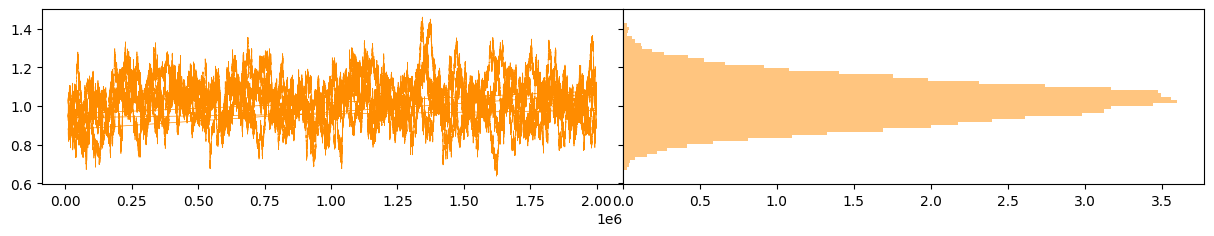

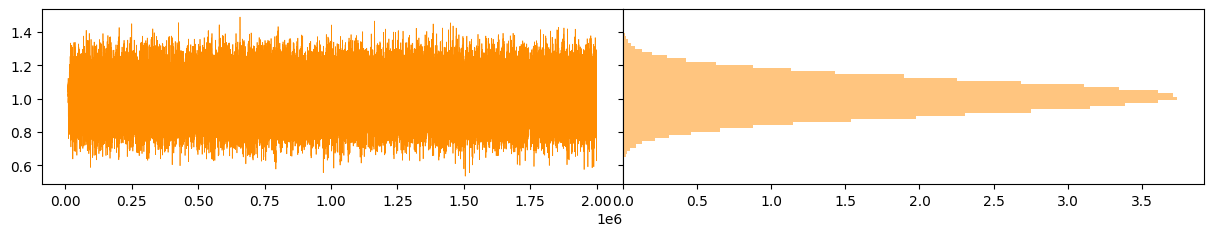

In [3]:
plotter_NADT2K=ChainDiagnostics(NAD_T2K_data)
plotter_ADT2K=ChainDiagnostics(AD_T2K_data)

plotter_NADT2K("xsec_10")
plotter_ADT2K("xsec_10")
plt.show()

## How does R* behave when 2 identical chain files slowly become more random.
> At what value of R* can we say with confidence that the ML Classifier distinguishes between the 2 chains as good as random guessing.

I have 8 files that each initially contain the exact same chain data. 

In [2]:
#this code is for all_fixed_AdT2K: the 2 files are identical
# NEXT STEP: add more folders that have increasing levels of randomness, use notebook to infer 
path_to_identical= Path("../models/demo_files 2/all_fixed_ADT2K/identical/")
path_to_1= Path("../models/demo_files 2/all_fixed_ADT2K/level_1/")
path_to_2= Path("../models/demo_files 2/all_fixed_ADT2K/level_2/")
path_to_3= Path("../models/demo_files 2/all_fixed_ADT2K/level_3/")
path_to_4= Path("../models/demo_files 2/all_fixed_ADT2K/level_4/")
path_to_5= Path("../models/demo_files 2/all_fixed_ADT2K/level_5/")
path_to_6= Path("../models/demo_files 2/all_fixed_ADT2K/level_6/")
path_to_7= Path("../models/demo_files 2/all_fixed_ADT2K/level_7/")

identical=[f"{path_to_identical}/{x}" for x in os.listdir(path_to_identical)] 
level1=[f'{path_to_1}/{y}' for y in os.listdir(path_to_1)]
level2=[f'{path_to_2}/{z}' for z in os.listdir(path_to_2)]
level3=[f'{path_to_3}/{a}' for a in os.listdir(path_to_3)]# these will be used later as args in functions (used to calc the dims of the data)
level4=[f'{path_to_4}/{b}' for b in os.listdir(path_to_4)]
level5=[f'{path_to_5}/{c}' for c in os.listdir(path_to_5)]
level6=[f'{path_to_6}/{b}' for b in os.listdir(path_to_6)]
level7=[f'{path_to_7}/{c}' for c in os.listdir(path_to_7)]




fitting_label = "ID"
paths = [identical, level1, level2, level3, level4,level5, level6, level7]
for i in paths:
    print(i)
# chain_list [for file in folder ChainHandler(input_file, chain_name, verbose=verbse)]: Handler List : Hlist

temp_identical=[]
temp1=[]
temp2=[]
temp3=[]
temp4=[]
temp5=[]
temp6=[]
temp7=[]



for lm in paths:
    for x in lm:
        chain_handler = ChainHandler(x, 'posteriors', verbose='verbose')
            
        # Process all the files
        chain_handler.ignore_plots(["xsec_20", "xsec_19", 'baseline', 'density', 'Ye'])
        chain_handler.add_additional_plots(["xsec_0", "xsec_1", "xsec_2", "xsec_3", "xsec_4", "xsec_5", "xsec_6", "xsec_7", "xsec_8", "xsec_9", "xsec_10", "xsec_11", "xsec_12", "xsec_13",
                                            "xsec_14", "xsec_15", "xsec_16", "xsec_17", "xsec_18", "xsec_21", "xsec_22"])
        chain_handler.add_additional_plots(['sin2th_12', 'sin2th_23', 'sin2th_13', 'delm2_12', 'delm2_23', 'delta_cp'])
        #We need to make sure the chain handler knows this exists, passing true means it is looking for some with that exact name
        # chain_handler.add_additional_plots(fitting_label, True)

        # Finally we can do some cuts to get rid of things like burn-in
        chain_handler.add_new_cuts(["LogL<22.5", "step>10000", "delm2_23>0"])
        chain_handler.add_new_cuts(["step>0", "LogL_systematic_xsec_cov<12345"])

        # Last step is  convert the chain data files into a pandas dataframe
        y= chain_handler.convert_ttree_to_array()
        #chain_list_2.append(chain_handler)


        if lm == identical:
            temp_identical.append(chain_handler)
        elif lm == level1:
            temp1.append(chain_handler)
        elif lm == level2:
            temp2.append(chain_handler)
        elif lm == level3:
            temp3.append(chain_handler)
        elif lm == level4:
            temp4.append(chain_handler)
        elif lm == level5:
            temp5.append(chain_handler)
        elif lm == level6:
            temp6.append(chain_handler)
        elif lm == level7:
            temp7.append(chain_handler)


identical_data = temp_identical[0]
identical_data.ttree_array['ID']= 0 #give the first file, containing chain data, the chain ID of 0

level1_data = temp1[0]
level1_data.ttree_array['ID']= 0

level2_data = temp2[0]
level2_data.ttree_array['ID']= 0

level3_data = temp3[0]
level3_data.ttree_array['ID']= 0

level4_data= temp4[0]
level4_data.ttree_array['ID']=0

level5_data= temp5[0]
level5_data.ttree_array['ID']=0

level6_data= temp6[0]
level6_data.ttree_array['ID']=0

level7_data= temp7[0]
level7_data.ttree_array['ID']=0

# double check if the uniform dist is applied by identifying row (chian id =1) and coloumn (i.e xsec_0)
from itertools import chain
concatenated = chain(range(19), range(21, 23))

for id, chain in enumerate(temp_identical[1:], start = 1): #iterate over the rest of the files and give it an acsending order Chain Ids starting from 1
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    #chain.ttree_array[f'xsec_{rand.randint(0,20)}']= np.random.random(size=len(chain.ttree_array))*1.2#on a random selection of parameters, change each value of that entire coloumn from a random float between 0 and 1
identical_data.ttree_array = pd.concat([identical_data.ttree_array, chain.ttree_array])

for id, chain in enumerate(temp1[1:], start = 1): 
    
    chain.ttree_array['ID'] = id
    for m in range(19):
        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*0.00001)
    level1_data.ttree_array = pd.concat([level1_data.ttree_array, chain.ttree_array])

for id, chain in enumerate(temp2[1:], start = 1): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(19):
        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*0.0001)
    level2_data.ttree_array = pd.concat([level2_data.ttree_array, chain.ttree_array])

for id, chain in enumerate(temp3[1:], start = 1): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(19):
        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*0.001)
    level3_data.ttree_array = pd.concat([level3_data.ttree_array, chain.ttree_array])

for id, chain in enumerate(temp4[1:], start = 1): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(19):
        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*0.01)
    level4_data.ttree_array = pd.concat([level4_data.ttree_array, chain.ttree_array])

for id, chain in enumerate(temp5[1:], start = 1): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(19):
        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*0.1)
    level5_data.ttree_array = pd.concat([level5_data.ttree_array, chain.ttree_array])

for id, chain in enumerate(temp6[1:], start = 1): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(19):
        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}'])))
    level6_data.ttree_array = pd.concat([level6_data.ttree_array, chain.ttree_array])


for id, chain in enumerate(temp7[1:], start = 1): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(19):
        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*10)
    level7_data.ttree_array = pd.concat([level7_data.ttree_array, chain.ttree_array])


#test to see if the code has actually randomly scaled the values:
xsec_values = identical_data.ttree_array[identical_data.ttree_array['ID'] == 1]
print(xsec_values)

l1 = level1_data.ttree_array[level1_data.ttree_array['ID'] == 1]['xsec_15']
print(l1)

l4 = level4_data.ttree_array[level4_data.ttree_array['ID'] == 1]['xsec_15']
print(l4)
l7 = level7_data.ttree_array[level7_data.ttree_array['ID'] == 1]['xsec_15']
print(l7)



# First step we need to initialise the factory
path_to_identical.parent.mkdir(parents=True, exist_ok=True)# Make sure the model output directory exists
print(fitting_label)
# The factory produces ML models, we need to pass it the chain handler and the fitting label to get started
ml_factory_id = MLFactory(identical_data, fitting_label, f"{path_to_identical}.pdf")

#hook up paths to MLFactory
path_to_1.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level1 = MLFactory(level1_data, fitting_label, f"{path_to_1}.pdf")

path_to_2.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level2 = MLFactory(level2_data, fitting_label, f"{path_to_2}.pdf")

path_to_3.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level3 = MLFactory(level3_data, fitting_label, f"{path_to_3}.pdf")

path_to_4.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level4 = MLFactory(level4_data, fitting_label, f"{path_to_4}.pdf")

path_to_5.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level5 = MLFactory(level5_data, fitting_label, f"{path_to_5}.pdf")

path_to_6.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level6 = MLFactory(level6_data, fitting_label, f"{path_to_6}.pdf")

path_to_7.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level7 = MLFactory(level7_data, fitting_label, f"{path_to_7}.pdf")


count = (level1_data.ttree_array['ID'] == 0).sum()
print(count)

count2 = count = (level1_data.ttree_array['ID'] == 1).sum()
print(count2)



['../models/demo_files 2/all_fixed_ADT2K/identical/mcmc_Adapt_T2K_all_fixed_dupe2.root', '../models/demo_files 2/all_fixed_ADT2K/identical/mcmc_Adapt_T2K_all_fixed_dupe.root']
['../models/demo_files 2/all_fixed_ADT2K/level_1/mcmc_Adapt_T2K_all_fixed_dupe2.root', '../models/demo_files 2/all_fixed_ADT2K/level_1/mcmc_Adapt_T2K_all_fixed_dupe.root']
['../models/demo_files 2/all_fixed_ADT2K/level_2/mcmc_Adapt_T2K_all_fixed_dupe2.root', '../models/demo_files 2/all_fixed_ADT2K/level_2/mcmc_Adapt_T2K_all_fixed_dupe.root']
['../models/demo_files 2/all_fixed_ADT2K/level_3/mcmc_Adapt_T2K_all_fixed_dupe2.root', '../models/demo_files 2/all_fixed_ADT2K/level_3/mcmc_Adapt_T2K_all_fixed_dupe.root']
['../models/demo_files 2/all_fixed_ADT2K/level_4/mcmc_Adapt_T2K_all_fixed_dupe2.root', '../models/demo_files 2/all_fixed_ADT2K/level_4/mcmc_Adapt_T2K_all_fixed_dupe.root']
['../models/demo_files 2/all_fixed_ADT2K/level_5/mcmc_Adapt_T2K_all_fixed_dupe2.root', '../models/demo_files 2/all_fixed_ADT2K/level_5/m

In [3]:
print(identical)

['../models/demo_files 2/all_fixed_ADT2K/identical/mcmc_Adapt_T2K_all_fixed_dupe2.root', '../models/demo_files 2/all_fixed_ADT2K/identical/mcmc_Adapt_T2K_all_fixed_dupe.root']


### Run the cell below for diagnostics: Confusion Matrix, Loss function plots, etc

Training Model
Binning 0.533 GB of training data: 0.902 s
Binning 0.059 GB of validation data: 0.087 s
Fitting gradient boosted rounds:
[1/20] 1 tree, 550 leaves, max depth = 25, train loss: 0.69313, val loss: 0.69318, in 0.488s
[2/20] 1 tree, 550 leaves, max depth = 23, train loss: 0.69311, val loss: 0.69322, in 0.366s
[3/20] 1 tree, 550 leaves, max depth = 26, train loss: 0.69309, val loss: 0.69325, in 0.363s
[4/20] 1 tree, 550 leaves, max depth = 25, train loss: 0.69307, val loss: 0.69329, in 0.372s
[5/20] 1 tree, 550 leaves, max depth = 21, train loss: 0.69305, val loss: 0.69332, in 0.298s
[6/20] 1 tree, 550 leaves, max depth = 25, train loss: 0.69303, val loss: 0.69336, in 0.348s
[7/20] 1 tree, 550 leaves, max depth = 20, train loss: 0.69301, val loss: 0.69339, in 0.381s
[8/20] 1 tree, 550 leaves, max depth = 26, train loss: 0.69299, val loss: 0.69342, in 0.379s
[9/20] 1 tree, 550 leaves, max depth = 24, train loss: 0.69297, val loss: 0.69346, in 0.290s
[10/20] 1 tree, 550 leaves,

Number of independent MCMCs: 2

Training Results!

[[739241 632243]
 [697414 673669]]

2

length of id list:2

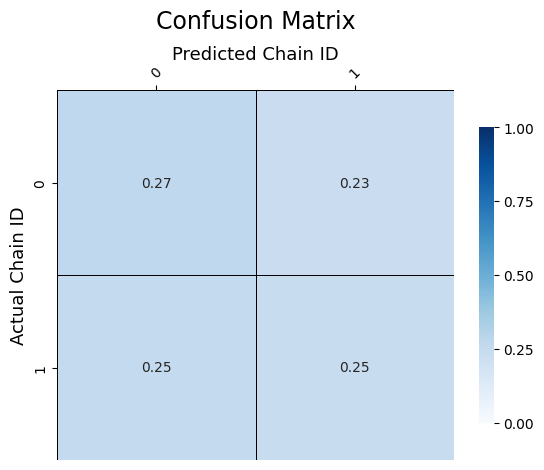

predictive accuracy: 0.5151779336657956

R*: 1.0303558673315911

=====

Testing Results!

train prediction:[0 0 1 ... 0 0 0]

train true:         ID
364661    0
308815    0
521751    1
1791369   0
1770496   0
...      ..
1052843   0
269009    0
513854    0
1563600   0
1822835   1

[2742567 rows x 1 columns]

[[286686 300807]
 [328513 259381]]

2

length of id list:2

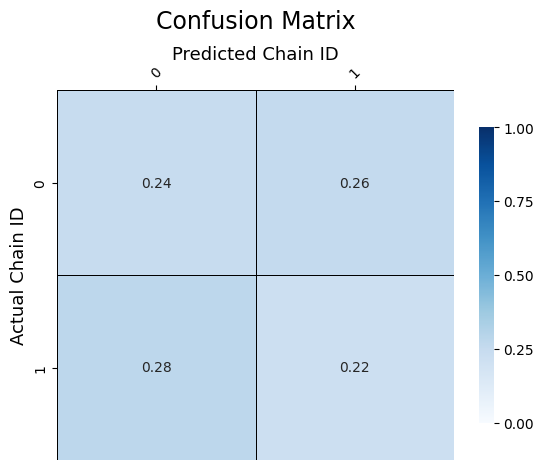

predictive accuracy: 0.46458485588150966

R*: 0.9291697117630193

=====

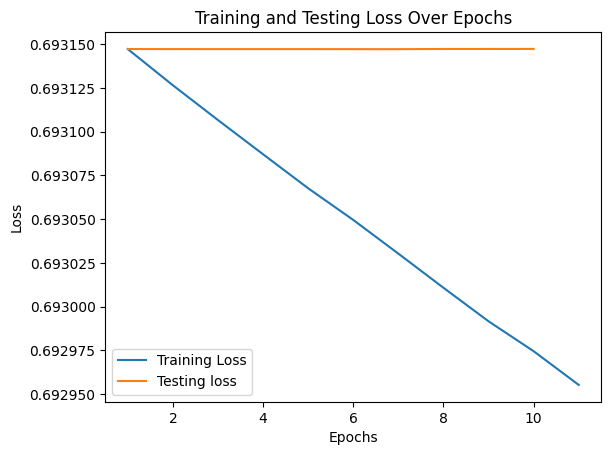

test prediction:[0 0 0 ... 1 1 0]

test true:         ID
1630898   1
1972633   0
53736     0
1490620   1
606287    0
...      ..
1263286   0
1508092   0
1346613   1
1636497   1
1084512   0

[1175387 rows x 1 columns]

<class 'numpy.ndarray'>

<class 'pandas.core.frame.DataFrame'>

Training Model
Binning 0.533 GB of training data: 1.255 s
Binning 0.059 GB of validation data: 0.184 s
Fitting gradient boosted rounds:
[1/20] 1 tree, 220 leaves, max depth = 21, train loss: 0.69312, val loss: 0.69318, in 0.329s
[2/20] 1 tree, 220 leaves, max depth = 27, train loss: 0.69310, val loss: 0.69321, in 0.277s
[3/20] 1 tree, 220 leaves, max depth = 17, train loss: 0.69308, val loss: 0.69324, in 0.231s
[4/20] 1 tree, 220 leaves, max depth = 19, train loss: 0.69306, val loss: 0.69327, in 0.253s
[5/20] 1 tree, 220 leaves, max depth = 21, train loss: 0.69303, val loss: 0.69330, in 0.289s
[6/20] 1 tree, 220 leaves, max depth = 25, train loss: 0.69301, val loss: 0.69333, in 0.207s
[7/20] 1 tree, 220 leaves, max depth = 19, train loss: 0.69299, val loss: 0.69336, in 0.241s
[8/20] 1 tree, 220 leaves, max depth = 25, train loss: 0.69297, val loss: 0.69339, in 0.276s
[9/20] 1 tree, 220 leaves, max depth = 22, train loss: 0.69295, val loss: 0.69341, in 0.253s
[10/20] 1 tree, 220 leaves,

Number of independent MCMCs: 2

Training Results!

[[766090 605665]
 [738535 632277]]

2

length of id list:2

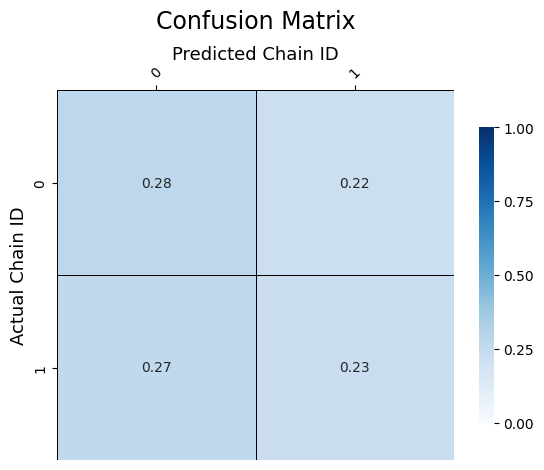

predictive accuracy: 0.5098752373232814

R*: 1.0197504746465629

=====

Testing Results!

train prediction:[0 0 0 ... 0 0 1]

train true:         ID
685805    1
1069871   0
846961    0
385939    0
149602    1
...      ..
1039294   1
772032    0
1657205   0
1770274   0
473065    0

[2742567 rows x 1 columns]

[[309908 277314]
 [335052 253113]]

2

length of id list:2

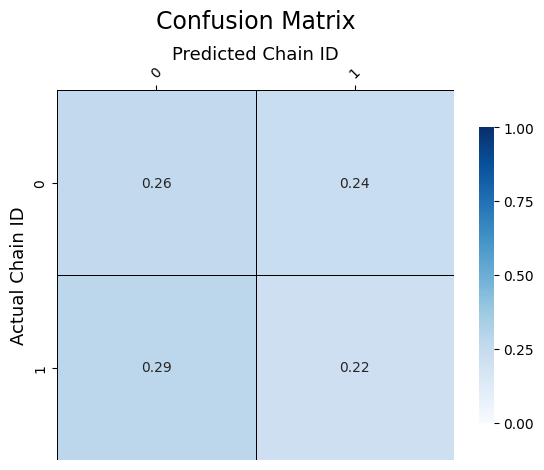

predictive accuracy: 0.47900904127746863

R*: 0.9580180825549373

=====

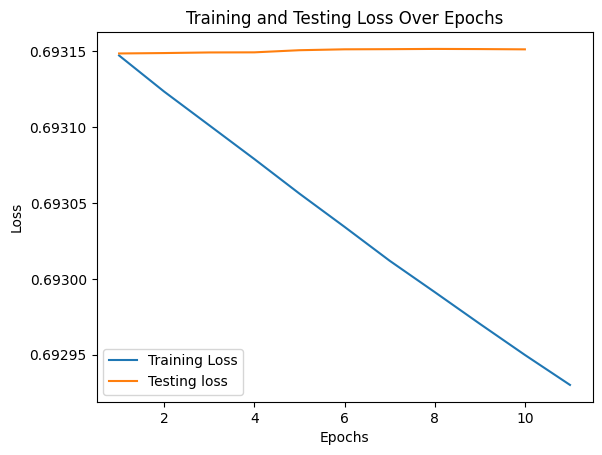

test prediction:[0 0 1 ... 0 0 0]

test true:         ID
706631    0
1747368   0
1116635   0
1622861   0
1190625   0
...      ..
1098090   1
1550459   0
930286    1
1501397   1
1481845   1

[1175387 rows x 1 columns]

<class 'numpy.ndarray'>

<class 'pandas.core.frame.DataFrame'>

Training Model
Binning 0.533 GB of training data: 0.775 s
Binning 0.059 GB of validation data: 0.089 s
Fitting gradient boosted rounds:
[1/20] 1 tree, 100 leaves, max depth = 17, train loss: 0.69313, val loss: 0.69316, in 0.180s
[2/20] 1 tree, 100 leaves, max depth = 16, train loss: 0.69312, val loss: 0.69317, in 0.123s
[3/20] 1 tree, 100 leaves, max depth = 21, train loss: 0.69310, val loss: 0.69318, in 0.114s
[4/20] 1 tree, 100 leaves, max depth = 18, train loss: 0.69308, val loss: 0.69318, in 0.155s
[5/20] 1 tree, 100 leaves, max depth = 18, train loss: 0.69307, val loss: 0.69319, in 0.147s
[6/20] 1 tree, 100 leaves, max depth = 19, train loss: 0.69305, val loss: 0.69320, in 0.137s
[7/20] 1 tree, 100 leaves, max depth = 17, train loss: 0.69304, val loss: 0.69321, in 0.145s
[8/20] 1 tree, 100 leaves, max depth = 16, train loss: 0.69302, val loss: 0.69321, in 0.115s
[9/20] 1 tree, 100 leaves, max depth = 15, train loss: 0.69301, val loss: 0.69321, in 0.126s
[10/20] 1 tree, 100 leaves,

Number of independent MCMCs: 2

Training Results!

[[785013 586621]
 [771696 599237]]

2

length of id list:2

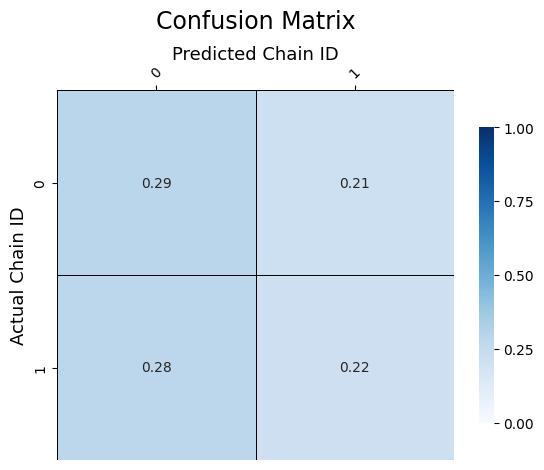

predictive accuracy: 0.5047278699116557

R*: 1.0094557398233115

=====

Testing Results!

train prediction:[1 0 0 ... 0 0 0]

train true:         ID
377689    0
346648    0
1684535   1
1189010   1
1754856   1
...      ..
658397    0
854873    0
1933277   1
1167391   1
1080277   1

[2742567 rows x 1 columns]

[[329156 258187]
 [338307 249737]]

2

length of id list:2

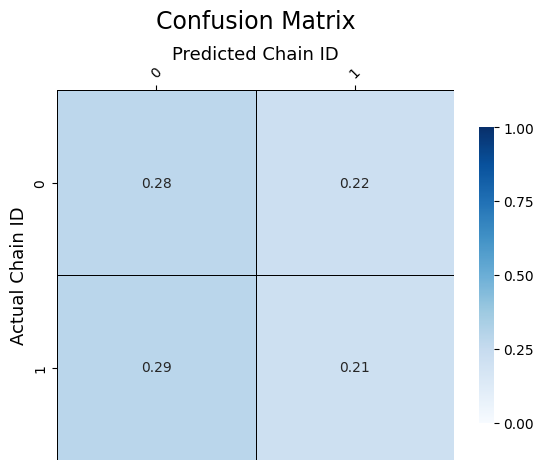

predictive accuracy: 0.49251267880281135

R*: 0.9850253576056227

=====

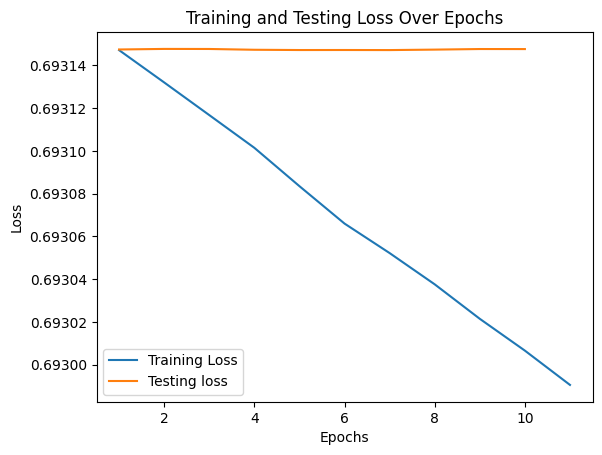

test prediction:[1 0 0 ... 0 0 0]

test true:         ID
936361    1
1297651   0
1230098   1
1057422   0
420902    1
...      ..
1302315   1
1811126   0
1994438   1
418415    1
1604747   1

[1175387 rows x 1 columns]

<class 'numpy.ndarray'>

<class 'pandas.core.frame.DataFrame'>

Training Model
Binning 0.533 GB of training data: 0.780 s
Binning 0.059 GB of validation data: 0.097 s
Fitting gradient boosted rounds:
[1/20] 1 tree, 100 leaves, max depth = 21, train loss: 0.69313, val loss: 0.69313, in 0.093s
[2/20] 1 tree, 100 leaves, max depth = 19, train loss: 0.69311, val loss: 0.69312, in 0.105s
[3/20] 1 tree, 100 leaves, max depth = 16, train loss: 0.69309, val loss: 0.69310, in 0.079s
[4/20] 1 tree, 100 leaves, max depth = 15, train loss: 0.69307, val loss: 0.69309, in 0.096s
[5/20] 1 tree, 100 leaves, max depth = 17, train loss: 0.69306, val loss: 0.69308, in 0.085s
[6/20] 1 tree, 100 leaves, max depth = 21, train loss: 0.69305, val loss: 0.69307, in 0.093s
[7/20] 1 tree, 100 leaves, max depth = 18, train loss: 0.69303, val loss: 0.69305, in 0.090s
[8/20] 1 tree, 100 leaves, max depth = 14, train loss: 0.69301, val loss: 0.69304, in 0.081s
[9/20] 1 tree, 100 leaves, max depth = 15, train loss: 0.69299, val loss: 0.69303, in 0.088s
[10/20] 1 tree, 100 leaves,

Number of independent MCMCs: 2

Training Results!

[[1103032  268538]
 [1083757  287240]]

2

length of id list:2

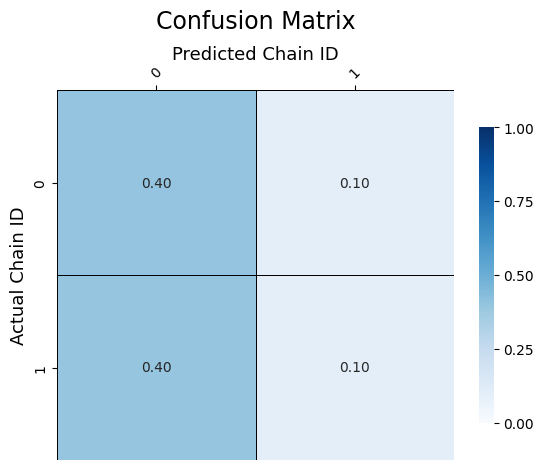

predictive accuracy: 0.506923623014497

R*: 1.013847246028994

=====

Testing Results!

train prediction:[0 0 0 ... 0 0 0]

train true:         ID
1993530   1
768309    0
516788    0
1314413   0
1430575   0
...      ..
494627    1
476779    1
1625998   1
1780837   0
286598    1

[2742567 rows x 1 columns]

[[470764 116643]
 [466495 121485]]

2

length of id list:2

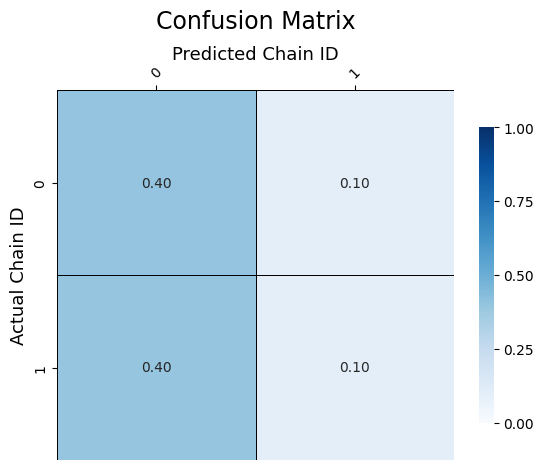

predictive accuracy: 0.5038757447547063

R*: 1.0077514895094126

=====

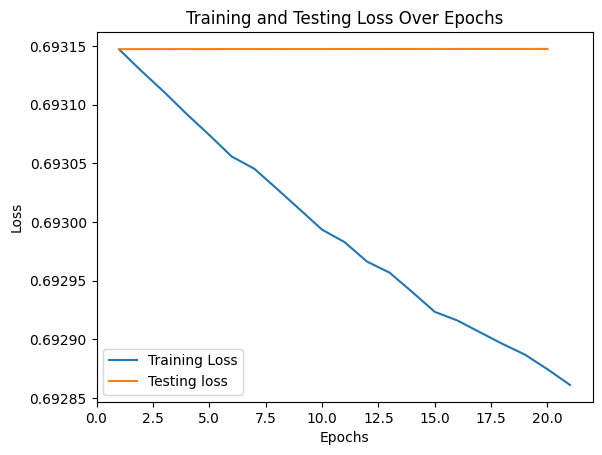

test prediction:[0 0 0 ... 0 0 0]

test true:         ID
1266198   0
648329    0
1004841   0
102061    0
1457873   0
...      ..
1285939   0
459406    1
483379    1
1734547   0
1364173   0

[1175387 rows x 1 columns]

<class 'numpy.ndarray'>

<class 'pandas.core.frame.DataFrame'>

Training Model
Binning 0.533 GB of training data: 0.780 s
Binning 0.059 GB of validation data: 0.081 s
Fitting gradient boosted rounds:
[1/20] 1 tree, 690 leaves, max depth = 32, train loss: 0.69251, val loss: 0.69264, in 0.507s
[2/20] 1 tree, 690 leaves, max depth = 30, train loss: 0.69158, val loss: 0.69188, in 0.701s
[3/20] 1 tree, 690 leaves, max depth = 27, train loss: 0.69082, val loss: 0.69131, in 0.377s
[4/20] 1 tree, 690 leaves, max depth = 28, train loss: 0.68955, val loss: 0.69018, in 0.518s
[5/20] 1 tree, 690 leaves, max depth = 27, train loss: 0.68867, val loss: 0.68944, in 0.579s
[6/20] 1 tree, 690 leaves, max depth = 29, train loss: 0.68795, val loss: 0.68888, in 0.305s
[7/20] 1 tree, 690 leaves, max depth = 30, train loss: 0.68690, val loss: 0.68801, in 0.388s
[8/20] 1 tree, 690 leaves, max depth = 29, train loss: 0.68606, val loss: 0.68732, in 0.335s
[9/20] 1 tree, 690 leaves, max depth = 29, train loss: 0.68554, val loss: 0.68693, in 0.244s
[10/20] 1 tree, 690 leaves,

Number of independent MCMCs: 2

Training Results!

[[1139138  232980]
 [ 836641  533808]]

2

length of id list:2

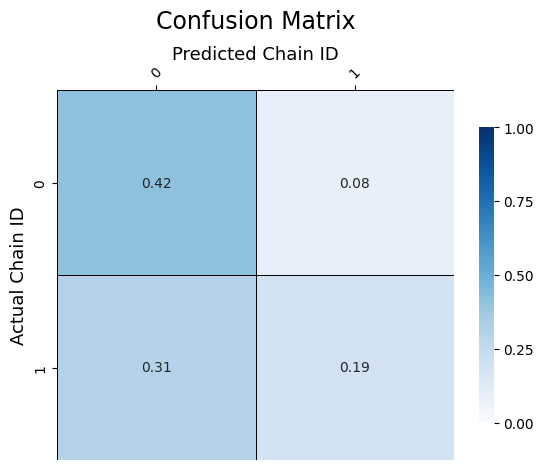

predictive accuracy: 0.6099927549627776

R*: 1.2199855099255552

=====

Testing Results!

train prediction:[1 1 1 ... 0 0 0]

train true:         ID
1403985   1
1932018   1
455519    0
595755    0
26531     1
...      ..
1009037   1
75216     0
1708381   0
637648    1
909189    0

[2742567 rows x 1 columns]

[[478077 108782]
 [369622 218906]]

2

length of id list:2

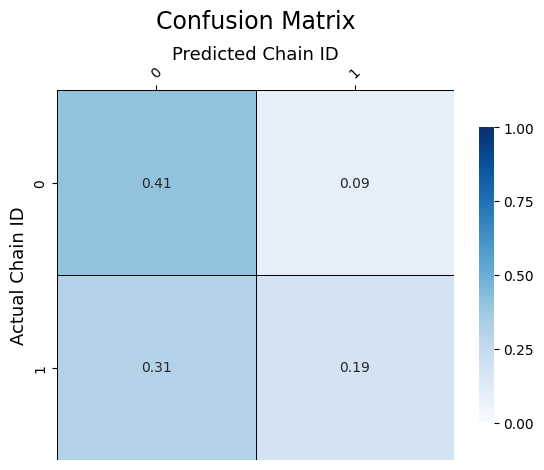

predictive accuracy: 0.5929817158093462

R*: 1.1859634316186924

=====

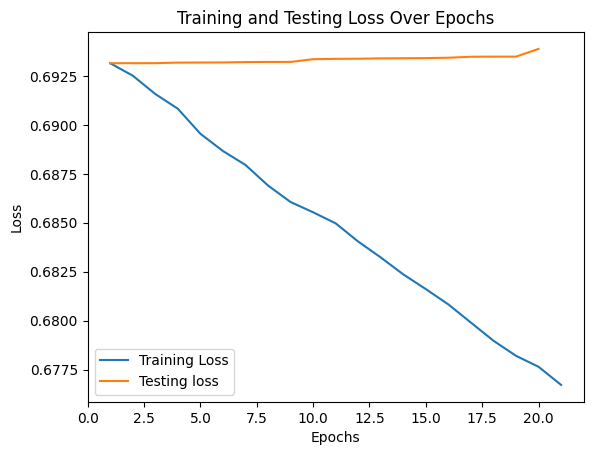

test prediction:[0 1 0 ... 0 1 0]

test true:         ID
1030268   0
13783     0
167033    0
1205105   1
695954    1
...      ..
1976759   0
1192044   1
927743    0
29667     1
714047    0

[1175387 rows x 1 columns]

<class 'numpy.ndarray'>

<class 'pandas.core.frame.DataFrame'>

Training Model
Binning 0.533 GB of training data: 0.869 s
Binning 0.059 GB of validation data: 0.108 s
Fitting gradient boosted rounds:
[1/20] 1 tree, 300 leaves, max depth = 20, train loss: 0.63903, val loss: 0.63907, in 0.455s
[2/20] 1 tree, 300 leaves, max depth = 22, train loss: 0.59280, val loss: 0.59290, in 0.600s
[3/20] 1 tree, 300 leaves, max depth = 19, train loss: 0.55292, val loss: 0.55307, in 1.140s
[4/20] 1 tree, 300 leaves, max depth = 18, train loss: 0.51821, val loss: 0.51841, in 0.415s
[5/20] 1 tree, 300 leaves, max depth = 20, train loss: 0.48782, val loss: 0.48810, in 0.379s
[6/20] 1 tree, 300 leaves, max depth = 21, train loss: 0.46106, val loss: 0.46139, in 0.396s
[7/20] 1 tree, 300 leaves, max depth = 19, train loss: 0.43747, val loss: 0.43783, in 0.404s
[8/20] 1 tree, 300 leaves, max depth = 19, train loss: 0.41648, val loss: 0.41688, in 0.506s
[9/20] 1 tree, 300 leaves, max depth = 20, train loss: 0.39776, val loss: 0.39820, in 0.479s
[10/20] 1 tree, 300 leaves,

Number of independent MCMCs: 2

Training Results!

[[1319793   50825]
 [ 179907 1192042]]

2

length of id list:2

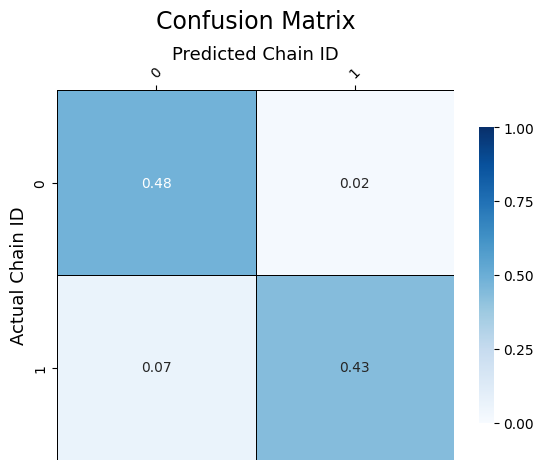

predictive accuracy: 0.915870058963008

R*: 1.831740117926016

=====

Testing Results!

train prediction:[0 1 0 ... 1 0 1]

train true:         ID
1514593   0
15503     1
168348    0
609672    1
245511    1
...      ..
942915    1
1073634   0
1895434   1
1353643   0
177407    1

[2742567 rows x 1 columns]

[[565874  22485]
 [ 77904 509124]]

2

length of id list:2

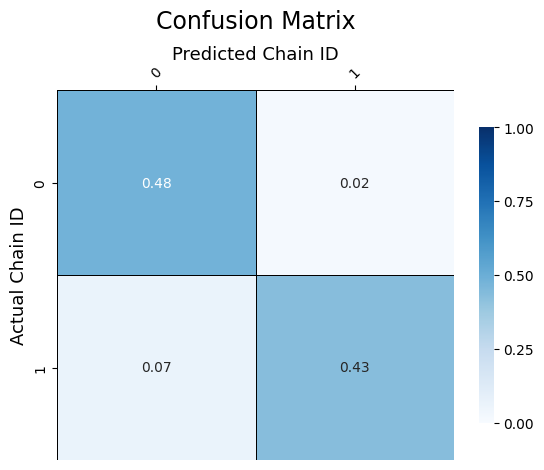

predictive accuracy: 0.9145906837492672

R*: 1.8291813674985344

=====

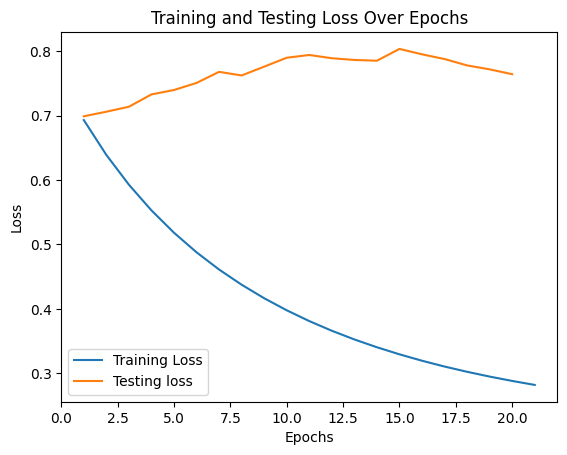

test prediction:[0 0 0 ... 1 1 1]

test true:         ID
1156836   0
147884    0
267762    0
1676956   0
582664    0
...      ..
1043211   1
1120548   1
1624625   1
464516    1
244337    1

[1175387 rows x 1 columns]

<class 'numpy.ndarray'>

<class 'pandas.core.frame.DataFrame'>

Training Model
Binning 0.533 GB of training data: 0.771 s
Binning 0.059 GB of validation data: 0.100 s
Fitting gradient boosted rounds:
[1/20] 1 tree, 80 leaves, max depth = 18, train loss: 0.61305, val loss: 0.61306, in 0.133s
[2/20] 1 tree, 80 leaves, max depth = 17, train loss: 0.54537, val loss: 0.54537, in 0.171s
[3/20] 1 tree, 80 leaves, max depth = 19, train loss: 0.48726, val loss: 0.48727, in 0.137s
[4/20] 1 tree, 80 leaves, max depth = 16, train loss: 0.43706, val loss: 0.43707, in 0.162s
[5/20] 1 tree, 80 leaves, max depth = 17, train loss: 0.39312, val loss: 0.39314, in 0.153s
[6/20] 1 tree, 80 leaves, max depth = 21, train loss: 0.35451, val loss: 0.35453, in 0.161s
[7/20] 1 tree, 80 leaves, max depth = 20, train loss: 0.32038, val loss: 0.32041, in 0.140s
[8/20] 1 tree, 80 leaves, max depth = 19, train loss: 0.29009, val loss: 0.29012, in 0.128s
[9/20] 1 tree, 80 leaves, max depth = 20, train loss: 0.26310, val loss: 0.26313, in 0.150s
[10/20] 1 tree, 80 leaves, max depth

Number of independent MCMCs: 2

Training Results!

[[1370843      49]
 [      1 1371674]]

2

length of id list:2

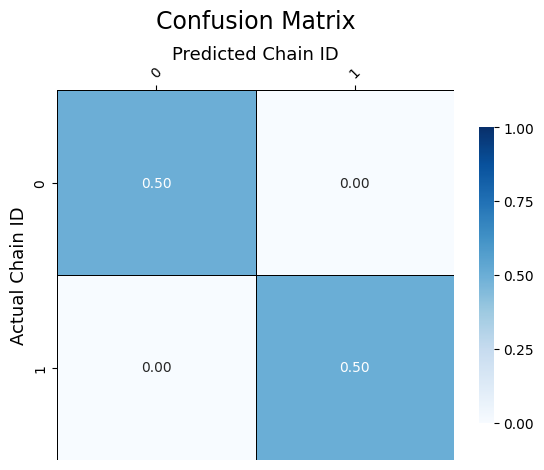

predictive accuracy: 0.9999817689048253

R*: 1.9999635378096505

=====

Testing Results!

train prediction:[1 0 0 ... 0 0 0]

train true:         ID
624580    1
1403154   0
833765    0
1774715   0
13608     0
...      ..
656794    1
1457887   1
1073697   0
1864547   0
412501    0

[2742567 rows x 1 columns]

[[588061     24]
 [     1 587301]]

2

length of id list:2

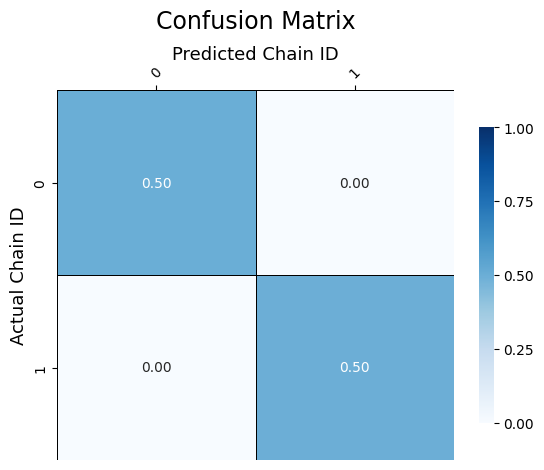

predictive accuracy: 0.9999787304096438

R*: 1.9999574608192876

=====

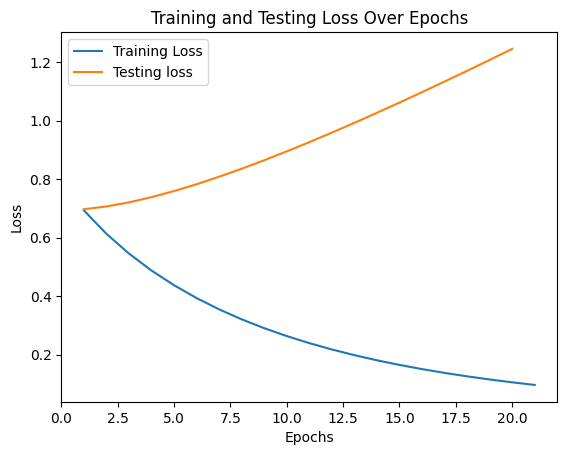

test prediction:[1 0 0 ... 1 1 0]

test true:         ID
232313    1
1400393   0
1228609   0
1165462   0
1978611   1
...      ..
1883859   0
379864    1
683778    1
1109417   1
1133378   0

[1175387 rows x 1 columns]

<class 'numpy.ndarray'>

<class 'pandas.core.frame.DataFrame'>

Training Model
Binning 0.533 GB of training data: 0.853 s
Binning 0.059 GB of validation data: 0.079 s
Fitting gradient boosted rounds:
[1/20] 1 tree, 19 leaves, max depth = 10, train loss: 0.66031, val loss: 0.66030, in 0.143s
[2/20] 1 tree, 29 leaves, max depth = 11, train loss: 0.62959, val loss: 0.62959, in 0.127s
[3/20] 1 tree, 20 leaves, max depth = 12, train loss: 0.60079, val loss: 0.60079, in 0.106s
[4/20] 1 tree, 28 leaves, max depth = 11, train loss: 0.57374, val loss: 0.57374, in 0.106s
[5/20] 1 tree, 22 leaves, max depth = 11, train loss: 0.54829, val loss: 0.54829, in 0.111s
[6/20] 1 tree, 25 leaves, max depth = 11, train loss: 0.52431, val loss: 0.52431, in 0.105s
[7/20] 1 tree, 10 leaves, max depth = 9, train loss: 0.50167, val loss: 0.50167, in 0.100s
[8/20] 1 tree, 32 leaves, max depth = 11, train loss: 0.48027, val loss: 0.48027, in 0.116s
[9/20] 1 tree, 37 leaves, max depth = 10, train loss: 0.46002, val loss: 0.46002, in 0.126s
[10/20] 1 tree, 33 leaves, max depth 

Number of independent MCMCs: 2

Training Results!

[[1371326       0]
 [      0 1371241]]

2

length of id list:2

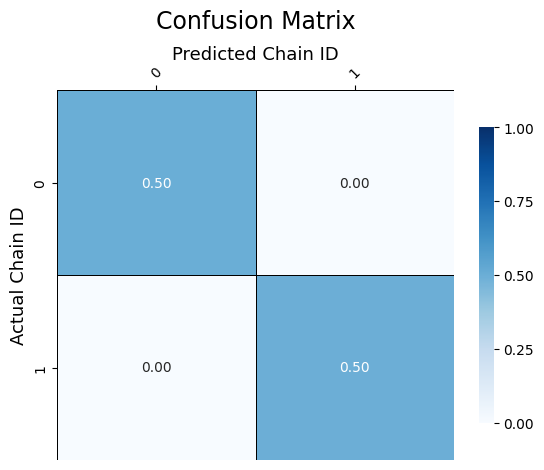

predictive accuracy: 1.0

R*: 2.0

=====

Testing Results!

train prediction:[1 0 0 ... 1 0 0]

train true:         ID
1822762   1
1219668   0
1208937   0
979491    0
944536    1
...      ..
1680785   1
1250516   1
1592867   1
429417    0
695344    0

[2742567 rows x 1 columns]

[[587651      0]
 [     0 587736]]

2

length of id list:2

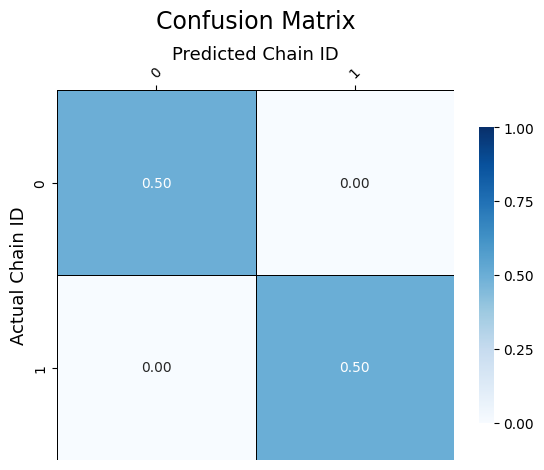

predictive accuracy: 1.0

R*: 2.0

=====

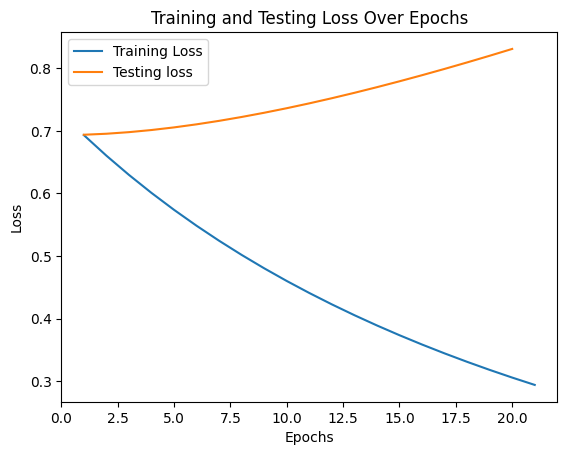

test prediction:[0 1 1 ... 0 1 1]

test true:         ID
829942    0
467003    1
1798485   1
1254670   0
235772    1
...      ..
513907    1
178085    1
166095    0
1332134   1
1907659   1

[1175387 rows x 1 columns]

<class 'numpy.ndarray'>

<class 'pandas.core.frame.DataFrame'>

In [ ]:

ml_model_id = ml_factory_id.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.0257, max_iter=20, verbose=2, max_leaf_nodes=550, 
                                                   l2_regularization= 0.962, max_features=1.0, early_stopping=True, n_iter_no_change= 10) #contains identical data
ml_model_id.set_training_test_set(0.3)
ml_model_id.train_model()
print(f'results for identical:')
print('=========================')
ml_model_id.test_model_class(identical,'adapt', 't2k', norm=  False, model= ml_model_id)

ml_model_1 = ml_factory_level1.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.07020000000000001, max_iter=20, verbose=2, max_leaf_nodes=220, 
                                                   l2_regularization= 0.8250000000000001, max_features=0.5, early_stopping=True, n_iter_no_change= 10)#contains level1 data
ml_model_1.set_training_test_set(0.3)
ml_model_1.train_model()
print(f'results for level 1:')
print('=========================')
ml_model_1.test_model_class(level1, 'adapt', 't2k', norm= False, model=ml_model_1)


ml_model_2 = ml_factory_level2.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.0868, max_iter=20, verbose=2, max_leaf_nodes=100, 
                                                   l2_regularization= 0.395, max_features= 0.5, early_stopping=True, n_iter_no_change= 10)
ml_model_2.set_training_test_set(0.3)
ml_model_2.train_model()
print(f'results for level 2:')
print('=========================')
ml_model_2.test_model_class(level2, 'adapt', 't2k', norm= False, model=ml_model_2)

ml_model_3 = ml_factory_level3.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.0152, max_iter=20, verbose=2, max_leaf_nodes=100, 
                                                   l2_regularization= 0.87, max_features= 0.5, early_stopping=True, n_iter_no_change= 10)
ml_model_3.set_training_test_set(0.3)
ml_model_3.train_model()
print(f'results for level 3:')
print('=========================')
ml_model_3.test_model_class(level3, 'adapt', 't2k', norm= False, model=ml_model_3)


ml_model_4 = ml_factory_level4.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.09000000000000001, max_iter=20, verbose=2, max_leaf_nodes=690, 
                                                   l2_regularization= 0.08700000000000001, max_features=0.4, early_stopping=True, n_iter_no_change= 10)
ml_model_4.set_training_test_set(0.3)
ml_model_4.train_model()
print(f'results for level 4:')
print('=========================')

ml_model_4.test_model_class(level4, 'adapt', 't2k', norm= False, model=ml_model_4)




ml_model_5 = ml_factory_level5.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.07940000000000001, max_iter=20, verbose=2, max_leaf_nodes=300, 
                                                   l2_regularization= 0.295, max_features= 0.9, early_stopping=True, n_iter_no_change= 10)
ml_model_5.set_training_test_set(0.3)
ml_model_5.train_model()
print(f'results for level 5:')
print('=========================')
ml_model_5.test_model_class(level5, 'adapt', 't2k', norm=  False, model=ml_model_5)


ml_model_6 = ml_factory_level6.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.08370000000000001, max_iter=20, verbose=2, max_leaf_nodes=80, 
                                                   l2_regularization= 0.303, max_features=0.7000000000000001, early_stopping=True, n_iter_no_change= 10)
ml_model_6.set_training_test_set(0.3)
ml_model_6.train_model()
print(f'results for level 6:')
print('=========================')
ml_model_6.test_model_class(level6, 'adapt', 't2k', norm= False, model=ml_model_6) 


ml_model_7 = ml_factory_level7.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.033400000000000006, max_iter=20, verbose=2, max_leaf_nodes=630, 
                                                   l2_regularization= 0.004, max_features= 0.4, early_stopping=True, n_iter_no_change= 10)
ml_model_7.set_training_test_set(0.3)
ml_model_7.train_model()
print(f'results for level 7:')
print('=========================')
ml_model_7.test_model_class(level7, 'adapt', 't2k', norm= False, model=ml_model_7)




In [ ]:

hist = level7_data.ttree_array['delm2_23'][level7_data.ttree_array['ID']==0].hist()
plt.show()
hist2 = level7_data.ttree_array['delm2_23'][level7_data.ttree_array['ID']==1].hist() 
plt.show()

### Calc multiple R* vals for each level and then plot them with error bars

In [5]:
ml_model_id = ml_factory_id.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.0257, max_iter=20, verbose=1, max_leaf_nodes=550, 
                                                   l2_regularization= 0.962, max_features=1.0, early_stopping=True, n_iter_no_change= 10) #contains identical data
ml_model_1 = ml_factory_level1.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.07020000000000001, max_iter=20, verbose=1, max_leaf_nodes=220, 
                                                   l2_regularization= 0.8250000000000001, max_features=0.5, early_stopping=True, n_iter_no_change= 10)#contains level1 data)
ml_model_2 = ml_factory_level2.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.0868, max_iter=20, verbose=1, max_leaf_nodes=100, 
                                                   l2_regularization= 0.395, max_features= 0.5, early_stopping=True, n_iter_no_change= 10)

ml_model_3 = ml_factory_level3.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.0152, max_iter=20, verbose=1, max_leaf_nodes=100, 
                                                   l2_regularization= 0.87, max_features= 0.5, early_stopping=True, n_iter_no_change= 10)
ml_model_4 = ml_factory_level4.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.09000000000000001, max_iter=20, verbose=1, max_leaf_nodes=690, 
                                                   l2_regularization= 0.08700000000000001, max_features=0.4, early_stopping=True, n_iter_no_change= 10)
ml_model_5 = ml_factory_level5.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.07940000000000001, max_iter=20, verbose=1, max_leaf_nodes=300, 
                                                   l2_regularization= 0.295, max_features= 0.9, early_stopping=True, n_iter_no_change= 10)
ml_model_6 = ml_factory_level6.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.08370000000000001, max_iter=20, verbose=1, max_leaf_nodes=80, 
                                                   l2_regularization= 0.303, max_features=0.7000000000000001, early_stopping=True, n_iter_no_change= 10)
ml_model_7 = ml_factory_level7.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.033400000000000006, max_iter=20, verbose=1, max_leaf_nodes=630, 
                                                   l2_regularization= 0.004, max_features= 0.4, early_stopping=True, n_iter_no_change= 10)
list_id=[]
list1=[]
list2=[]
list3=[]
list4=[]
list5=[]
list6=[]
list7=[]


datapoints= 3
for i in range(datapoints):
    ml_model_id.set_training_test_set(0.3)
    ml_model_id.train_model()
    y=ml_model_id.getRStar_vals(identical, ml_model_id)
    list_id.append(y)

for i in range(datapoints):
    ml_model_1.set_training_test_set(0.3)
    ml_model_1.train_model()
    y=ml_model_1.getRStar_vals(level1, ml_model_1)
    list1.append(y)

for i in range(datapoints):
    ml_model_2.set_training_test_set(0.3)
    ml_model_2.train_model()
    y=ml_model_2.getRStar_vals(level2, ml_model_2)
    list2.append(y)

for i in range(datapoints):
    ml_model_3.set_training_test_set(0.3)
    ml_model_3.train_model()
    y=ml_model_3.getRStar_vals(level3, ml_model_3)
    list3.append(y)

for i in range(datapoints):
    ml_model_4.set_training_test_set(0.3)
    ml_model_4.train_model()
    y=ml_model_4.getRStar_vals(level4, ml_model_4)
    list4.append(y)

for i in range(datapoints):
    ml_model_5.set_training_test_set(0.3)
    ml_model_5.train_model()
    y=ml_model_5.getRStar_vals(level5, ml_model_5)
    list5.append(y)

for i in range(datapoints):
    ml_model_6.set_training_test_set(0.3)
    ml_model_6.train_model()
    y=ml_model_6.getRStar_vals(level6, ml_model_6)
    list6.append(y)
    

for i in range(datapoints):
    ml_model_7.set_training_test_set(0.3)
    ml_model_7.train_model()
    y=ml_model_7.getRStar_vals(identical, ml_model_7)
    list7.append(y)





Training Model
Binning 0.533 GB of training data: 0.794 s
Binning 0.059 GB of validation data: 0.090 s
Fitting gradient boosted rounds:
Fit 10 trees in 6.996 s, (5500 total leaves)
Time spent computing histograms: 2.064s
Time spent finding best splits:  0.424s
Time spent applying splits:      0.678s
Time spent predicting:           0.034s


Number of independent MCMCs: 2 detected.

R* incoming

predictive accuracy: 0.46568066517666096

R*: 0.9313613303533219

...

Training Model
Binning 0.533 GB of training data: 0.669 s
Binning 0.059 GB of validation data: 0.089 s
Fitting gradient boosted rounds:
Fit 20 trees in 4.781 s, (650 total leaves)
Time spent computing histograms: 1.676s
Time spent finding best splits:  0.131s
Time spent applying splits:      0.505s
Time spent predicting:           0.039s


Number of independent MCMCs: 2 detected.

R* incoming

predictive accuracy: 1.0

R*: 2.0

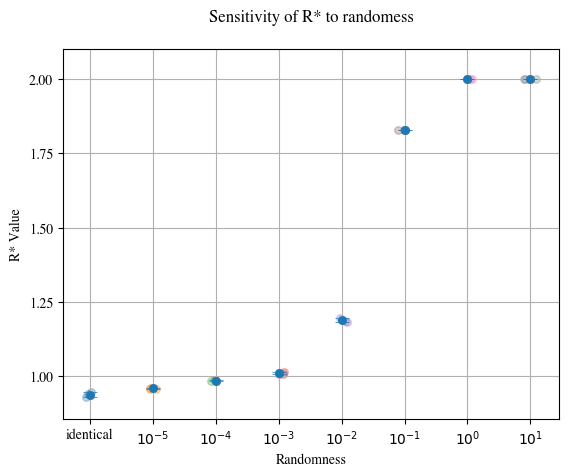

   labels     Mean      Min      Max  Lower Error  Upper Error
identical 0.939097 0.931361 0.946267     0.007736     0.007170
$10^{-5}$ 0.959836 0.958008 0.961891     0.001829     0.002054
$10^{-4}$ 0.985852 0.983872 0.987009     0.001981     0.001157
$10^{-3}$ 1.010566 1.006727 1.016321     0.003839     0.005755
$10^{-2}$ 1.188298 1.181868 1.196294     0.006430     0.007996
$10^{-1}$ 1.828873 1.828378 1.829149     0.000495     0.000276
 $10^{0}$ 1.999946 1.999937 1.999954     0.000009     0.000009
 $10^{1}$ 2.000000 2.000000 2.000000     0.000000     0.000000


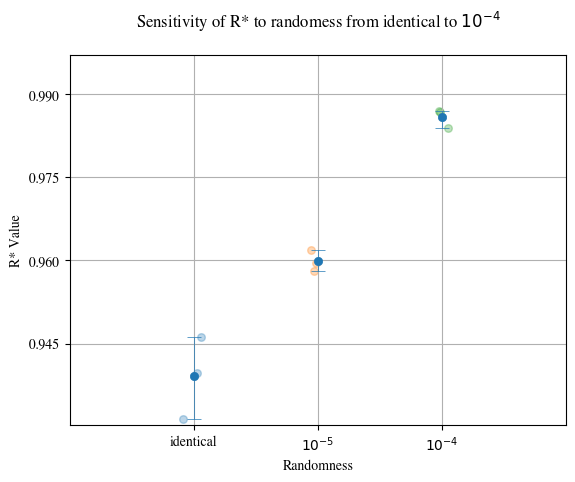

In [36]:

lists=[list_id, list1, list2, list3, list4, list5, list6, list7]
concat= list_id + list1 + list2 + list3 + list4 + list5 + list6 +list7

means = np.array([np.mean(vals) for vals in lists])
mins  = np.array([np.min(vals)  for vals in lists])
maxs  = np.array([np.max(vals)  for vals in lists])

lower_err = means - mins
upper_err = maxs  - means
yerr = np.vstack((lower_err, upper_err))


x = np.arange(len(lists)) + 2   

plt.errorbar(x, means,
             yerr=yerr,
             fmt='o',        
             capsize=5,      
             elinewidth=0.5,
             markeredgewidth=0.5)


labels = ['identical',r'$10^{-5}$', r'$10^{-4}$', r'$10^{-3}$', r'$10^{-2}$', r'$10^{-1}$', r'$10^{0}$', r'$10^{1}$']
datapoints = 2
def add_jitter(x, scale=0.2): #scales x-datapoints so that they don't overlap.
    return x + np.random.uniform(-scale, scale, size=len(x))

for xi, vals in zip(x, lists):
    jittered =    jittered_x = add_jitter([xi]*len(vals), scale=0.1)
    plt.scatter(jittered, vals, alpha=0.3, s=30)

plt.xticks([2, 3, 4, 5, 6, 7, 8, 9], [labels[0], labels[1], labels[2], labels[3], labels[4], labels[5], labels[6], labels[7]])

ymin, ymax = min(concat), max(concat)
pad    = (ymax - ymin) * 0.2
plt.ylim(ymin - pad, ymax + pad)
plt.ylim(min(list1)-0.1, max(list7)+0.1)

plt.gca().yaxis.set_major_locator(plt.MaxNLocator(5))   
plt.rcParams["font.family"] = "Times"
plt.title('Sensitivity of R* to randomess', pad=20)
plt.xlabel('Randomness')
plt.ylabel('R* Value')
plt.savefig('filename.png', dpi=900)
plt.grid(True)
plt.show()



table = pd.DataFrame({
    'labels': labels,
    'Mean': means,
    'Min': mins,
    'Max': maxs,
    'Lower Error': lower_err,
    'Upper Error': upper_err
})

print(table.to_string(index=False))

lists=[list_id, list1, list2]

for xi, vals in zip(x, lists):
    jittered =    jittered_x = add_jitter([xi]*len(vals), scale=0.1)
    plt.scatter(jittered, vals, alpha=0.3, s=30)

plt.errorbar(x, means,
             yerr=yerr,
             fmt='o',        
             capsize=5,      
             elinewidth=0.5,
             markeredgewidth=0.5)


plt.xticks([2, 3, 4], [labels[0], labels[1], labels[2]])
ymin, ymax = min(concat), max(concat)
#pad    = (ymax - ymin) * 0.1
#plt.ylim(ymin - pad, ymax + pad)
plt.ylim(min(list_id)-0.001, max(list2)+0.01)

plt.gca().yaxis.set_major_locator(plt.MaxNLocator(5))   
plt.xlim([1, 5])
plt.rcParams["font.family"] = "Times"
plt.title('Sensitivity of R* to randomess from identical to 'r'$10^{-4}$', pad=20)
plt.xlabel('Randomness')
plt.ylabel('R* Value')
plt.savefig('filename.png', dpi=900)
plt.grid(True)
plt.show()



### Shifting values for a single parameter

In [ ]:
#this code is for all_fixed_AdT2K: the 2 files are identical
# NEXT STEP: add more folders that have increasing levels of randomness, use notebook to infer 
path_to_identical= Path("../models/demo_files 2/all_fixed_ADT2K/identical/")
path_to_1= Path("../models/demo_files 2/all_fixed_ADT2K/level_1/")
path_to_2= Path("../models/demo_files 2/all_fixed_ADT2K/level_2/")
path_to_3= Path("../models/demo_files 2/all_fixed_ADT2K/level_3/")
path_to_4= Path("../models/demo_files 2/all_fixed_ADT2K/level_4/")
path_to_5= Path("../models/demo_files 2/all_fixed_ADT2K/level_5/")
path_to_6= Path("../models/demo_files 2/all_fixed_ADT2K/level_6/")
path_to_7= Path("../models/demo_files 2/all_fixed_ADT2K/level_7/")

identical=[f"{path_to_identical}/{x}" for x in os.listdir(path_to_identical)] 
level1=[f'{path_to_1}/{y}' for y in os.listdir(path_to_1)]
level2=[f'{path_to_2}/{z}' for z in os.listdir(path_to_2)]
level3=[f'{path_to_3}/{a}' for a in os.listdir(path_to_3)]# these will be used later as args in functions (used to calc the dims of the data)
level4=[f'{path_to_4}/{b}' for b in os.listdir(path_to_4)]
level5=[f'{path_to_5}/{c}' for c in os.listdir(path_to_5)]
level6=[f'{path_to_6}/{b}' for b in os.listdir(path_to_6)]
level7=[f'{path_to_7}/{c}' for c in os.listdir(path_to_7)]




fitting_label = "ID"
paths = [identical, level1, level2, level3, level4,level5, level6, level7]
for i in paths:
    print(i)
# chain_list [for file in folder ChainHandler(input_file, chain_name, verbose=verbse)]: Handler List : Hlist

temp_identical=[]
temp1=[]
temp2=[]
temp3=[]
temp4=[]
temp5=[]
temp6=[]
temp7=[]



for lm in paths:
    for x in lm:
        chain_handler = ChainHandler(x, 'posteriors', verbose='verbose')
            
        # Process all the files
        chain_handler.ignore_plots(["xsec_20", "xsec_19", 'sin2th_12', 'sin2th_23', 'sin2th_13', 'delm2_12', 'delm2_23', 'delta_cp', 'baseline', 'density', 'Ye'])
        chain_handler.add_additional_plots(["xsec_0", "xsec_1", "xsec_2", "xsec_3", "xsec_4", "xsec_5", "xsec_6", "xsec_7", "xsec_8", "xsec_9", "xsec_10", "xsec_11", "xsec_12", "xsec_13",
                                            "xsec_14", "xsec_15", "xsec_16", "xsec_17", "xsec_18", "xsec_21", "xsec_22"])
        #We need to make sure the chain handler knows this exists, passing true means it is looking for some with that exact name
        # chain_handler.add_additional_plots(fitting_label, True)

        # Finally we can do some cuts to get rid of things like burn-in
        chain_handler.add_new_cuts(["LogL<22.5", "step>10000", "delm2_23>0"])
        chain_handler.add_new_cuts(["step>0", "LogL_systematic_xsec_cov<12345"])

        # Last step is  convert the chain data files into a pandas dataframe
        y= chain_handler.convert_ttree_to_array()
        #chain_list_2.append(chain_handler)


        if lm == identical:
            temp_identical.append(chain_handler)
        elif lm == level1:
            temp1.append(chain_handler)
        elif lm == level2:
            temp2.append(chain_handler)
        elif lm == level3:
            temp3.append(chain_handler)
        elif lm == level4:
            temp4.append(chain_handler)
        elif lm == level5:
            temp5.append(chain_handler)
        elif lm == level6:
            temp6.append(chain_handler)
        elif lm == level7:
            temp7.append(chain_handler)


identical_data = temp_identical[0]
identical_data.ttree_array['ID']= 0 #give the first file, containing chain data, the chain ID of 0

level1_data = temp1[0]
level1_data.ttree_array['ID']= 0

level2_data = temp2[0]
level2_data.ttree_array['ID']= 0

level3_data = temp3[0]
level3_data.ttree_array['ID']= 0

level4_data= temp4[0]
level4_data.ttree_array['ID']=0

level5_data= temp5[0]
level5_data.ttree_array['ID']=0

level6_data= temp6[0]
level6_data.ttree_array['ID']=0

level7_data= temp7[0]
level7_data.ttree_array['ID']=0

# double check if the uniform dist is applied by identifying row (chian id =1) and coloumn (i.e xsec_0)
from itertools import chain
concatenated = chain(range(19), range(21, 23))

for id, chain in enumerate(temp_identical[1:], start = 1): #iterate over the rest of the files and give it an acsending order Chain Ids starting from 1
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    #chain.ttree_array[f'xsec_{rand.randint(0,20)}']= np.random.random(size=len(chain.ttree_array))*1.2#on a random selection of parameters, change each value of that entire coloumn from a random float between 0 and 1
identical_data.ttree_array = pd.concat([identical_data.ttree_array, chain.ttree_array])

for id, chain in enumerate(temp1[1:], start = 1): 
    
    chain.ttree_array['ID'] = id
    for m in range(1):
        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*0.00001)
    level1_data.ttree_array = pd.concat([level1_data.ttree_array, chain.ttree_array])

for id, chain in enumerate(temp2[1:], start = 1): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(1):
        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*0.0001)
    level2_data.ttree_array = pd.concat([level2_data.ttree_array, chain.ttree_array])

for id, chain in enumerate(temp3[1:], start = 1): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(1):
        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*0.001)
    level3_data.ttree_array = pd.concat([level3_data.ttree_array, chain.ttree_array])

for id, chain in enumerate(temp4[1:], start = 1): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(1):
        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*0.01)
    level4_data.ttree_array = pd.concat([level4_data.ttree_array, chain.ttree_array])

for id, chain in enumerate(temp5[1:], start = 1): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(1):
        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*0.1)
    level5_data.ttree_array = pd.concat([level5_data.ttree_array, chain.ttree_array])

for id, chain in enumerate(temp6[1:], start = 1): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(1):
        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}'])))
    level6_data.ttree_array = pd.concat([level6_data.ttree_array, chain.ttree_array])


for id, chain in enumerate(temp7[1:], start = 1): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(1):
        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*10)
    level7_data.ttree_array = pd.concat([level7_data.ttree_array, chain.ttree_array])


# First step we need to initialise the factory
path_to_identical.parent.mkdir(parents=True, exist_ok=True)# Make sure the model output directory exists
print(fitting_label)
# The factory produces ML models, we need to pass it the chain handler and the fitting label to get started
ml_factory_id = MLFactory(identical_data, fitting_label, f"{path_to_identical}.pdf")

#hook up paths to MLFactory
path_to_1.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level1 = MLFactory(level1_data, fitting_label, f"{path_to_1}.pdf")

path_to_2.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level2 = MLFactory(level2_data, fitting_label, f"{path_to_2}.pdf")

path_to_3.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level3 = MLFactory(level3_data, fitting_label, f"{path_to_3}.pdf")

path_to_4.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level4 = MLFactory(level4_data, fitting_label, f"{path_to_4}.pdf")

path_to_5.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level5 = MLFactory(level5_data, fitting_label, f"{path_to_5}.pdf")

path_to_6.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level6 = MLFactory(level6_data, fitting_label, f"{path_to_6}.pdf")

path_to_7.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level7 = MLFactory(level7_data, fitting_label, f"{path_to_7}.pdf")

# make graph better/ increase the y axis but not much, make more points 



In [ ]:

ml_model_id = ml_factory_id.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.0257, max_iter=20, verbose=2, max_leaf_nodes=550, 
                                                   l2_regularization= 0.962, max_features=1.0, early_stopping=True, n_iter_no_change= 10) #contains identical data
ml_model_id.set_training_test_set(0.3)
ml_model_id.train_model()
print(f'results for identical:')
print('=========================')
ml_model_id.test_model_class(identical, 'adapt', 't2k', norm= True, model=ml_model_id)


ml_model_1 = ml_factory_level1.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.07020000000000001, max_iter=20, verbose=2, max_leaf_nodes=220, 
                                                   l2_regularization= 0.8250000000000001, max_features=0.5, early_stopping=True, n_iter_no_change= 10)#contains level1 data
ml_model_1.set_training_test_set(0.3)
ml_model_1.train_model()
print(f'results for level 1:')
print('=========================')
ml_model_1.test_model_class(level1, 'adapt', 't2k', norm= False, model=ml_model_1)


ml_model_2 = ml_factory_level2.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.0868, max_iter=20, verbose=2, max_leaf_nodes=100, 
                                                   l2_regularization= 0.395, max_features= 0.5, early_stopping=True, n_iter_no_change= 10)
ml_model_2.set_training_test_set(0.3)
ml_model_2.train_model()
print(f'results for level 2:')
print('=========================')
ml_model_2.test_model_class(level2, 'adapt', 't2k', norm= False, model=ml_model_2)

ml_model_3 = ml_factory_level3.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.0152, max_iter=20, verbose=2, max_leaf_nodes=100, 
                                                   l2_regularization= 0.87, max_features= 0.5, early_stopping=True, n_iter_no_change= 10)
ml_model_3.set_training_test_set(0.3)
ml_model_3.train_model()
print(f'results for level 3:')
print('=========================')
ml_model_3.test_model_class(level3, 'adapt', 't2k', norm= False, model=ml_model_3)


ml_model_4 = ml_factory_level4.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.09000000000000001, max_iter=20, verbose=2, max_leaf_nodes=690, 
                                                   l2_regularization= 0.08700000000000001, max_features=0.4, early_stopping=True, n_iter_no_change= 10)
ml_model_4.set_training_test_set(0.3)
ml_model_4.train_model()
print(f'results for level 4:')
print('=========================')

ml_model_4.test_model_class(level4, 'adapt', 't2k', norm= False, model=ml_model_4)




ml_model_5 = ml_factory_level5.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.07940000000000001, max_iter=20, verbose=2, max_leaf_nodes=300, 
                                                   l2_regularization= 0.295, max_features= 0.9, early_stopping=True, n_iter_no_change= 10)
ml_model_5.set_training_test_set(0.3)
ml_model_5.train_model()
print(f'results for level 5:')
print('=========================')
ml_model_5.test_model_class(level5, 'adapt', 't2k', norm= False, model=ml_model_5)


ml_model_6 = ml_factory_level6.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.08370000000000001, max_iter=20, verbose=2, max_leaf_nodes=80, 
                                                   l2_regularization= 0.303, max_features=0.7000000000000001, early_stopping=True, n_iter_no_change= 10)
ml_model_6.set_training_test_set(0.3)
ml_model_6.train_model()
print(f'results for level 6:')
print('=========================')
ml_model_6.test_model_class(level6, 'adapt', 't2k', norm= False, model=ml_model_6) 


ml_model_7 = ml_factory_level7.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.033400000000000006, max_iter=20, verbose=2, max_leaf_nodes=630, 
                                                   l2_regularization= 0.004, max_features= 0.4, early_stopping=True, n_iter_no_change= 10)
ml_model_7.set_training_test_set(0.3)
ml_model_7.train_model()
print(f'results for level 7:')
print('=========================')
ml_model_7.test_model_class(level7, 'adapt', 't2k', norm= False, model=ml_model_7)




In [ ]:
ml_model_id = ml_factory_id.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.0257, max_iter=20, verbose=1, max_leaf_nodes=550, 
                                                   l2_regularization= 0.962, max_features=1.0, early_stopping=True, n_iter_no_change= 10) #contains identical data
ml_model_1 = ml_factory_level1.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.07020000000000001, max_iter=20, verbose=1, max_leaf_nodes=220, 
                                                   l2_regularization= 0.8250000000000001, max_features=0.5, early_stopping=True, n_iter_no_change= 10)#contains level1 data)
ml_model_2 = ml_factory_level2.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.0868, max_iter=20, verbose=1, max_leaf_nodes=100, 
                                                   l2_regularization= 0.395, max_features= 0.5, early_stopping=True, n_iter_no_change= 10)

ml_model_3 = ml_factory_level3.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.0152, max_iter=20, verbose=1, max_leaf_nodes=100, 
                                                   l2_regularization= 0.87, max_features= 0.5, early_stopping=True, n_iter_no_change= 10)
ml_model_4 = ml_factory_level4.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.09000000000000001, max_iter=20, verbose=1, max_leaf_nodes=690, 
                                                   l2_regularization= 0.08700000000000001, max_features=0.4, early_stopping=True, n_iter_no_change= 10)
ml_model_5 = ml_factory_level5.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.07940000000000001, max_iter=20, verbose=1, max_leaf_nodes=300, 
                                                   l2_regularization= 0.295, max_features= 0.9, early_stopping=True, n_iter_no_change= 10)
ml_model_6 = ml_factory_level6.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.08370000000000001, max_iter=20, verbose=1, max_leaf_nodes=80, 
                                                   l2_regularization= 0.303, max_features=0.7000000000000001, early_stopping=True, n_iter_no_change= 10)
ml_model_7 = ml_factory_level7.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.033400000000000006, max_iter=20, verbose=1, max_leaf_nodes=630, 
                                                   l2_regularization= 0.004, max_features= 0.4, early_stopping=True, n_iter_no_change= 10)
list_id=[]
list1=[]
list2=[]
list3=[]
list4=[]
list5=[]
list6=[]
list7=[]


datapoints= 3
for i in range(datapoints):
    ml_model_id.set_training_test_set(0.3)
    ml_model_id.train_model()
    y=ml_model_id.getRStar_vals(identical, ml_model_id)
    list_id.append(y)

for i in range(datapoints):
    ml_model_1.set_training_test_set(0.3)
    ml_model_1.train_model()
    y=ml_model_1.getRStar_vals(level1, ml_model_1)
    list1.append(y)

for i in range(datapoints):
    ml_model_2.set_training_test_set(0.3)
    ml_model_2.train_model()
    y=ml_model_2.getRStar_vals(level2, ml_model_2)
    list2.append(y)

for i in range(datapoints):
    ml_model_3.set_training_test_set(0.3)
    ml_model_3.train_model()
    y=ml_model_3.getRStar_vals(level3, ml_model_3)
    list3.append(y)

for i in range(datapoints):
    ml_model_4.set_training_test_set(0.3)
    ml_model_4.train_model()
    y=ml_model_4.getRStar_vals(level4, ml_model_4)
    list4.append(y)

for i in range(datapoints):
    ml_model_5.set_training_test_set(0.3)
    ml_model_5.train_model()
    y=ml_model_5.getRStar_vals(level5, ml_model_5)
    list5.append(y)

for i in range(datapoints):
    ml_model_6.set_training_test_set(0.3)
    ml_model_6.train_model()
    y=ml_model_6.getRStar_vals(level6, ml_model_6)
    list6.append(y)
    

for i in range(datapoints):
    ml_model_7.set_training_test_set(0.3)
    ml_model_7.train_model()
    y=ml_model_7.getRStar_vals(identical, ml_model_7)
    list7.append(y)





In [ ]:

lists=[list_id, list1, list2, list3, list4, list5, list6, list7]
concat= list_id + list1 + list2 + list3 + list4 + list5 + list6 +list7

means = np.array([np.mean(vals) for vals in lists])
mins  = np.array([np.min(vals)  for vals in lists])
maxs  = np.array([np.max(vals)  for vals in lists])

lower_err = means - mins
upper_err = maxs  - means
yerr = np.vstack((lower_err, upper_err))


x = np.arange(len(lists)) + 2   

plt.errorbar(x, means,
             yerr=yerr,
             fmt='o',        
             capsize=5,      
             elinewidth=1.5,
             markeredgewidth=1)



datapoints = 2
def add_jitter(x, scale=0.2): #scales x-datapoints so that they don't overlap.
    return x + np.random.uniform(-scale, scale, size=len(x))
labels = ['identical',r'$10^{-5}$', r'$10^{-4}$', r'$10^{-3}$', r'$10^{-2}$', r'$10^{-1}$', r'$10^{0}$', r'$10^{1}$']
for xi, vals in zip(x, lists):
    jittered =    jittered_x = add_jitter([xi]*len(vals), scale=0.1)
    plt.scatter(jittered, vals, alpha=0.3, s=30)

plt.xticks([2, 3, 4, 5, 6, 7, 8, 9], ['identical','level 1', 'level 2', 'level 3', 'level 4', 'level 5', 'level 6', 'level 7'])

ymin, ymax = min(concat), max(concat)
pad    = (ymax - ymin) * 0.2
plt.ylim(ymin - pad, ymax + pad)
plt.ylim(min(list1)-0.1, max(list7)+0.1)

plt.gca().yaxis.set_major_locator(plt.MaxNLocator(5))   
plt.grid(True)
plt.savefig('filename.png', dpi=900)
plt.title('Sensitivity of R* to randomess')
plt.xlabel('Random Noise Variation')
plt.ylabel('R* Value')

plt.show()



table = pd.DataFrame({
    'labels': labels,
    'Mean': means,
    'Min': mins,
    'Max': maxs,
    'Lower Error': lower_err,
    'Upper Error': upper_err
})

print(table.to_string(index=False))

## Optimising Hyperparameters: RandomizedSearchCV
Given a dict input containing a distribution of hyperparams you want to optimise, and the estimator, it will randomly
draw from the distribution and train the model using it. Calling .best_params_ will output the values of the hyperparams that gave the best result.



+ <b><u>L2_regularisation</u></b>: This essentially applies a penalty (cuts leaves) that are deemed to be useless, this can help reduce over-fitting; increasing the value increases the penalty, the usual values are. from 0.1 to 1, anything from 1 to 10 can lead to under-fitting.

+ <b><u>max_iter</u></b>: changing this changes the actual number of iterations that the model makes

I would want to increase the max_iter value when I actually want to get optimised results, but this should be done in the background 

In [ ]:
# add more hyperparams to optimise

dist={
        'learning_rate': np.arange(0.0001, 0.1, 0.0001 ),
        'max_leaf_nodes': [i for i in range(20, 700, 10)],
        'max_features': np.arange(0.1, 1, 0.1),
        'l2_regularization': np.arange(0.001, 1, 0.001), 
        'max_iter': [20] 
    }

models = [ml_model_id, ml_model_1, ml_model_2, ml_model_3, ml_model_4, ml_model_5, ml_model_6, ml_model_7]


for model in models:
    clf = RandomizedSearchCV(estimator=model.model, param_distributions=dist, cv=5, n_iter=2)
    search = clf.fit(model.scale_data(model._training_data), model.scale_labels(model._training_labels))
    print(f"Best params for {model}: {search.best_params_}")


### Comparing R* values per experiment and per MCMC-type
I want to compare the R* values between T2K and NOvA in Adaptive folder and Non-Adaptive MCMC; maybe also compare the entire folders (aka AD versus Non-AD). Maybe I plot multiple R* vals from per exp and then plot 



In [ ]:
# have to run .test_model_class() on each model before running this
datapoints= 5

T2K_nonadapt= np.random.uniform(1.0, 1.5, 6)#ml_model_NADT2K.getRStar_vals(NAD_T2K, datapoints)
Nova_nonadapt= np.random.uniform(1.0, 1.5, 6)#ml_model_NADT2K.getRStar_vals(NAD_Nova, datapoints)
T2K_adapt=  np.random.uniform(1.0, 1.5, 6)#ml_model_NADT2K.getRStar_vals(AD_T2K, datapoints)
Nova_nonadapt= np.random.uniform(1.0, 1.5, 6)#ml_model_NADT2K.getRStar_vals(AD_Nova, datapoints)



params= {'MCMC-type':['T2K_nonadapt', 'Nova_nonadapt', 'T2K_adapt', 'Nova_nonadapt'],
         'R* Value': [T2K_nonadapt, Nova_nonadapt, T2K_adapt, Nova_nonadapt ]

}

df= pd.DataFrame(params)
print(df)


### Stochasticity of R*

The code below:
 
 - Calculates N values of R* (datapoints = N ), for each file (each file should contain a different number of chains)
 
 - Plots it on the same axis: R* value versus Number of Chains. 
 
 - A jitter-like function was used to offset datapoints by a small amount w/r to x-axis so that points can be distinguishable. 